In [2]:
# %%capture
# aaa
import pandas as pd
from pandas.api.types import is_integer_dtype as is_integer
from pandas.api.types import is_float_dtype as is_float

import numpy as np

import time

from google.cloud import bigquery

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold, StratifiedKFold

from sklearn.feature_selection import RFECV

from sklearn.metrics import auc, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, make_scorer, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

import random
import torch
import optuna
import os
import re
import gc
import shap
import logging
import optuna

### Callable Functions

In [3]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()

In [4]:
os.environ['KMP_DUPLICATE_LIB_OK']='True'

client = bigquery.Client()

### Load Data

In [6]:
# Get outcome
sql = """
SELECT
    a.asdb_member_key
    , index_dt
    , ip_risk
    , cdpsrx_scr
    , ip_rnk
    , cdpsrx_rnk
    , run_dt
    , final_score
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_member_index` AS a
LEFT JOIN
    `anbc-hcb-prod.cm_medicaid_hcb_prod.medicaid_core2_0_final_score_history` AS b
        ON a.asdb_member_key = b.asdb_member_key
        AND a.index_dt = b.run_dt
WHERE 1 = 1
"""
df_og = client.query(sql).to_dataframe() 

df_og.shape

(3476866, 8)

In [7]:
# Get features
sql = """
SELECT
    *
FROM
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_outcome_ip`
WHERE 1 = 1
"""
outcomes = client.query(sql).to_dataframe() 
outcomes.shape

(2191613, 8)

In [8]:
df_og = df_og.rename(columns={"emr_id": "individual_id"})

In [42]:
df = outcomes.merge(df_og, on='asdb_member_key', how='left')

In [10]:
df.head()

,asdb_member_key,index_dt_x,acute_ip_flag,sum_acute_ip_admits,sum_acute_calc_los,sum_acute_admit_los,sum_acute_paid_los,sum_acute_ip_cost,index_dt_y,ip_risk,cdpsrx_scr,ip_rnk,cdpsrx_rnk,run_dt,final_score
0,72788228,2023-11-01,0,0.0,0,0,0,0E-9,2023-06-01,0.014377,0.499227,68.7,49.7,2023-06-01,49.7
1,72725571,2023-11-01,0,0.0,0,0,0,0E-9,2023-05-01,0.006542,0.499227,4.7,53.6,2023-05-01,4.7
2,72589383,2023-11-01,0,0.0,0,0,0,0E-9,2022-10-01,0.009443,0.499227,46.2,59.2,2022-10-01,46.2
3,72741393,2023-11-01,0,0.0,0,0,0,0E-9,2022-10-01,0.013996,0.499227,13.4,42.3,2022-10-01,13.4
4,72500790,2023-11-01,0,0.0,0,0,0,0E-9,2023-06-01,0.007714,0.618880,17.0,67.8,2023-06-01,17.0


In [43]:
df.shape

(2191613, 15)

In [49]:
outcome_var = 'acute_ip_flag'

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 0:15], df.loc[:, outcome_var], test_size=0.2, random_state=35, stratify=df.loc[:, outcome_var])
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=35, stratify=y_test)


In [50]:
X_test['ip_risk'].isnull().sum()

11901

In [51]:
X_test = X_test[X_test['ip_risk'].notna()]

In [52]:
X_test.head()

,asdb_member_key,index_dt_x,acute_ip_flag,sum_acute_ip_admits,sum_acute_calc_los,sum_acute_admit_los,sum_acute_paid_los,sum_acute_ip_cost,index_dt_y,ip_risk,cdpsrx_scr,ip_rnk,cdpsrx_rnk,run_dt,final_score
1923739,520474948,2023-11-01,0,0.0,0,0,0,0E-9,2023-06-01,0.023846,2.080773,90.5,90.4,2023-06-01,97.1
1100041,350415960,2023-11-01,0,0.0,0,0,0,0E-9,2023-05-01,0.053504,0.983963,81.4,69.2,2023-05-01,87.1
380760,460877421,2023-11-01,0,0.0,0,0,0,0E-9,2022-10-01,0.006968,0.476756,8.5,20.8,2022-10-01,8.5
272300,72705624,2023-11-01,0,0.0,0,0,0,0E-9,2023-01-01,0.017337,4.496690,79.9,98.3,2023-01-01,85.4
802133,451317372,2023-11-01,0,0.0,0,0,0,0E-9,2023-04-01,0.006818,0.476756,6.8,17.4,2023-04-01,6.8


In [11]:
def check_label_distribution(y):
    # Count the number of occurrences of each label 
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()
    ratio = count_1 / count_0 if count_0 != 0 else np.inf
    print(count_0, count_1, ratio)
    #return count_0, count_1, ratio

print("Nov 2023 outcomes:")
check_label_distribution(df['acute_ip_flag'])

Nov 2023 outcomes:
2159651 31962 0.01479961345606304


In [54]:
X_test['rnk_scr'] = X_test['ip_rnk']/100

In [55]:
def calculate_metrics(baseline):
    # Probabilities of the positive class
    y_pred_test = X_test['ip_risk']
    y_test = X_test['acute_ip_flag']

    # Resetting the index of y_test for alignment
    y_test_reset = y_test.reset_index(drop=True)

    # ROC AUC Score
    roc_auc_test = roc_auc_score(y_test, y_pred_test)

    # Sorting indices by predicted probabilities in descending order
    idx = np.argsort(y_pred_test)[::-1]

    # Function to calculate metrics for a given cutoff percentile
    def calculate_percentile_metrics(y_test_reset, idx, percentile):
        cutoff = int(percentile * len(y_test_reset))  # Number of data points in the top percentile
        top_indices = idx[:cutoff]  # Indices of the top percentile predictions

        # Binary predictions for the top percentile
        predictions_binary = np.zeros(len(y_test_reset), dtype=int)
        predictions_binary[top_indices] = 1

        # Confusion matrix calculation
        tn, fp, fn, tp = confusion_matrix(y_test_reset, predictions_binary, labels=[0, 1]).ravel()

        # Performance metrics
        ppv = 100 * (tp / (tp + fp)) if (tp + fp) > 0 else 0  # Positive Predictive Value
        sensitivity = 100 * (tp / (tp + fn)) if (tp + fn) > 0 else 0  # Sensitivity or Recall

        # Lift calculation
        actual_positives_top_perc = y_test_reset[top_indices].sum()
        expected_positives = y_test_reset.sum() * percentile
        lift = actual_positives_top_perc / expected_positives if expected_positives > 0 else 0

        return lift, ppv, sensitivity

    lift_1_perc, ppv_1_perc, sensitivity_1_perc = calculate_percentile_metrics(y_test_reset, idx, 0.01)
    lift_10_perc, ppv_10_perc, sensitivity_10_perc = calculate_percentile_metrics(y_test_reset, idx, 0.10)

    return roc_auc_test, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc

### Model metric checks

In [56]:
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(X_test)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.8017111444742878
1% Lift:  16.152570480928688
1% PPV:  23.503861003861005
1% Sensitivity:  16.15257048092869
10% Lift:  5.402985074626866
10% PPV:  7.859693139052398
10% Sensitivity:  54.02985074626866


Text(0.5, 427.9555555555555, 'Predicted label')

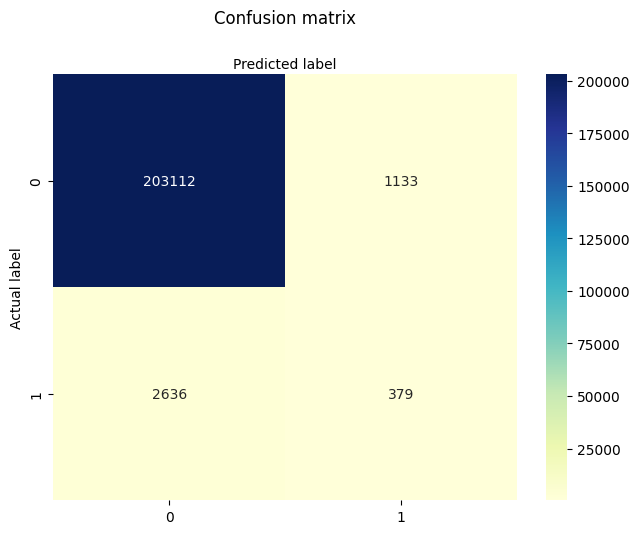

In [61]:
# Other metrics
y_pred_val = X_test['ip_risk']
y_pred_test_class = (y_pred_val >= .5).astype(int)
y_test = X_test['acute_ip_flag']

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [58]:
print(classification_report(y_test, y_pred_test_class))

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99   2159651
         1.0       0.25      0.12      0.16     31962

    accuracy                           0.98   2191613
   macro avg       0.62      0.56      0.58   2191613
weighted avg       0.98      0.98      0.98   2191613



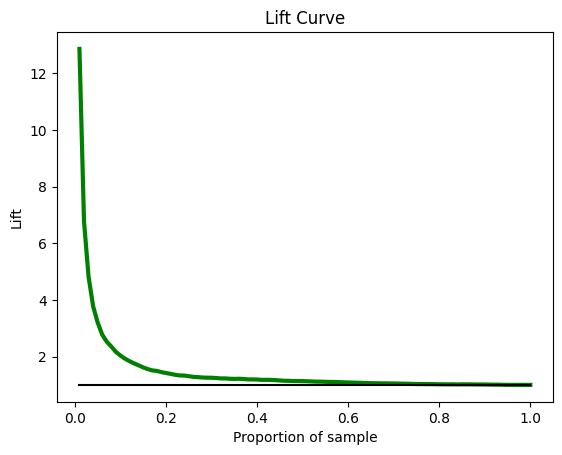

In [62]:
y_pred_val = X_test['ip_risk']
y_pred_test = (y_pred_val >= .5).astype(int)
plot_lift_curve(y_test, y_pred_test, step=0.01)

In [63]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_val)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

0.11875406337119186


In [64]:
X_test['y_predict_class'] = y_pred_test_class
X_test['y_predict_prob'] = X_test['ip_risk']

In [65]:
X_test['acute_ip_flag'] = X_test['acute_ip_flag'].astype(int) 

In [66]:
X_test.head()

,asdb_member_key,index_dt_x,acute_ip_flag,sum_acute_ip_admits,sum_acute_calc_los,sum_acute_admit_los,sum_acute_paid_los,sum_acute_ip_cost,index_dt_y,ip_risk,cdpsrx_scr,ip_rnk,cdpsrx_rnk,run_dt,final_score,rnk_scr,y_predict_class,y_predict_prob
1923739,520474948,2023-11-01,0,0.0,0,0,0,0E-9,2023-06-01,0.023846,2.080773,90.5,90.4,2023-06-01,97.1,0.905,0,0.023846
1100041,350415960,2023-11-01,0,0.0,0,0,0,0E-9,2023-05-01,0.053504,0.983963,81.4,69.2,2023-05-01,87.1,0.814,0,0.053504
380760,460877421,2023-11-01,0,0.0,0,0,0,0E-9,2022-10-01,0.006968,0.476756,8.5,20.8,2022-10-01,8.5,0.085,0,0.006968
272300,72705624,2023-11-01,0,0.0,0,0,0,0E-9,2023-01-01,0.017337,4.496690,79.9,98.3,2023-01-01,85.4,0.799,0,0.017337
802133,451317372,2023-11-01,0,0.0,0,0,0,0E-9,2023-04-01,0.006818,0.476756,6.8,17.4,2023-04-01,6.8,0.068,0,0.006818


In [69]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag']/len(df['acute_ip_flag'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag']
    df_data['Predict'] = df['ip_risk']>=0.5
    df_data['Prob_1'] = df['ip_risk']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum(numeric_only=True).Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df   

In [70]:
lift_chart(X_test)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.424939,487,2073,1.000193,16.152570,16.152570,1.000193,16.149454
1,0.424834,0.273277,238,2073,1.000193,7.893864,24.046434,2.000386,12.020897
2,0.273275,0.203115,173,2072,0.999711,5.737977,29.784411,3.000096,9.927818
3,0.203114,0.163915,127,2073,1.000193,4.212272,33.996683,4.000289,8.498556
4,0.163908,0.138226,140,2072,0.999711,4.643449,38.640133,5.000000,7.728027
...,...,...,...,...,...,...,...,...,...
95,0.002406,0.000922,21,2072,0.999711,0.696517,97.412935,95.999711,1.014721
96,0.000921,0.000428,10,2073,1.000193,0.331675,97.744610,96.999904,1.007677
97,0.000428,0.000005,19,2072,0.999711,0.630182,98.374793,97.999614,1.003828
98,0.000005,0.000000,25,2073,1.000193,0.829187,99.203980,98.999807,1.002062


In [71]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag']/len(df['acute_ip_flag'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag']
    df_data['Predict'] = df['ip_risk']>=0.5
    df_data['Prob_1'] = df['ip_risk']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum(numeric_only=True).Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df 

In [72]:
lift_chart(X_test)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.079935,1629,20726,10.0,54.029851,54.029851,10.0,5.402985
1,0.079931,0.044914,430,20726,10.0,14.262023,68.291874,20.0,3.414594
2,0.044914,0.030940,252,20726,10.0,8.358209,76.650083,30.0,2.555003
3,0.030939,0.023154,183,20726,10.0,6.069652,82.719735,40.0,2.067993
4,0.023154,0.018426,109,20726,10.0,3.615257,86.334992,50.0,1.726700
5,0.018426,0.014845,86,20726,10.0,2.852405,89.187396,60.0,1.486457
6,0.014845,0.011528,75,20726,10.0,2.487562,91.674959,70.0,1.309642
7,0.011528,0.008872,58,20726,10.0,1.923715,93.598673,80.0,1.169983
8,0.008872,0.007280,43,20726,10.0,1.426202,95.024876,90.0,1.055832
9,0.007279,0.000000,150,20726,10.0,4.975124,100.000000,100.0,1.000000
